<a href="https://colab.research.google.com/github/bishnudev1/MLOps/blob/main/EEG_Research.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset Link: https://www.kaggle.com/datasets/sravyaedara/eeg-signals-of-alzhiemers?resource=download

In [2]:
import kagglehub
path = kagglehub.dataset_download("sravyaedara/eeg-signals-of-alzhiemers")


100%|██████████| 2.10G/2.10G [00:26<00:00, 83.8MB/s]

Extracting files...


In [3]:
print("Path to dataset files:", path)

Path to dataset files: /root/.cache/kagglehub/datasets/sravyaedara/eeg-signals-of-alzhiemers/versions/1


In [4]:
import pandas as pd
participants_df = pd.read_csv(f"{path}/participants.tsv", sep="\t")


In [5]:
participants_df.head(10)

,participant_id,Gender,Age,Group,MMSE
0,sub-001,F,57,A,16
1,sub-002,F,78,A,22
2,sub-003,M,70,A,14
3,sub-004,F,67,A,20
4,sub-005,M,70,A,22
5,sub-006,F,61,A,14
6,sub-007,F,79,A,20
7,sub-008,M,62,A,16
8,sub-009,F,77,A,23
9,sub-010,M,69,A,20


In [6]:
label_map = {
    "C": 0,   # Healthy
    "A": 1,   # Alzheimer's
    "F": 2    # FTD
}

subject_to_label = {
    row["participant_id"]: label_map[row["Group"]]
    for _, row in participants_df.iterrows()
}


In [7]:
# Install required libraries (skip install if already installed locally)
!pip install mne numpy scipy scikit-learn matplotlib seaborn


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 61.1 MB/s eta 0:00:00


In [8]:
subject_to_label

{'sub-001': 1,
 'sub-002': 1,
 'sub-003': 1,
 'sub-004': 1,
 'sub-005': 1,
 'sub-006': 1,
 'sub-007': 1,
 'sub-008': 1,
 'sub-009': 1,
 'sub-010': 1,
 'sub-011': 1,
 'sub-012': 1,
 'sub-013': 1,
 'sub-014': 1,
 'sub-015': 1,
 'sub-016': 1,
 'sub-017': 1,
 'sub-018': 1,
 'sub-019': 1,
 'sub-020': 1,
 'sub-021': 1,
 'sub-022': 1,
 'sub-023': 1,
 'sub-024': 1,
 'sub-025': 1,
 'sub-026': 1,
 'sub-027': 1,
 'sub-028': 1,
 'sub-029': 1,
 'sub-030': 1,
 'sub-031': 1,
 'sub-032': 1,
 'sub-033': 1,
 'sub-034': 1,
 'sub-035': 1,
 'sub-036': 1,
 'sub-037': 0,
 'sub-038': 0,
 'sub-039': 0,
 'sub-040': 0,
 'sub-041': 0,
 'sub-042': 0,
 'sub-043': 0,
 'sub-044': 0,
 'sub-045': 0,
 'sub-046': 0,
 'sub-047': 0,
 'sub-048': 0,
 'sub-049': 0,
 'sub-050': 0,
 'sub-051': 0,
 'sub-052': 0,
 'sub-053': 0,
 'sub-054': 0,
 'sub-055': 0,
 'sub-056': 0,
 'sub-057': 0,
 'sub-058': 0,
 'sub-059': 0,
 'sub-060': 0,
 'sub-061': 0,
 'sub-062': 0,
 'sub-063': 0,
 'sub-064': 0,
 'sub-065': 0,
 'sub-066': 2,
 'sub-067'

In [9]:
import os
import glob
import re

import numpy as np
import pandas as pd

import mne

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns


In [10]:
base_path = "/root/.cache/kagglehub/datasets/sravyaedara/eeg-signals-of-alzhiemers/versions/1"

print(os.listdir(base_path))


['sub-006_task-eyesclosed_eeg.set', 'sub-002_task-eyesclosed_eeg.set', 'sub-084_task-eyesclosed_eeg.set', 'sub-083_task-eyesclosed_eeg.set', 'sub-062_task-eyesclosed_eeg.set', 'sub-087_task-eyesclosed_eeg.set', 'sub-019_task-eyesclosed_eeg.set', 'sub-015_task-eyesclosed_eeg.set', 'sub-059_task-eyesclosed_eeg.set', 'sub-025_task-eyesclosed_eeg.set', 'sub-013_task-eyesclosed_eeg.set', 'sub-072_task-eyesclosed_eeg.set', 'sub-042_task-eyesclosed_eeg.set', 'sub-043_task-eyesclosed_eeg.set', 'sub-008_task-eyesclosed_eeg.set', 'sub-060_task-eyesclosed_eeg.set', 'sub-058_task-eyesclosed_eeg.set', 'sub-010_task-eyesclosed_eeg.set', 'participants.json', 'sub-055_task-eyesclosed_eeg.set', 'sub-012_task-eyesclosed_eeg.set', 'sub-011_task-eyesclosed_eeg.set', 'sub-021_task-eyesclosed_eeg.set', 'sub-007_task-eyesclosed_eeg.set', 'participants.tsv', 'sub-088_task-eyesclosed_eeg.set', 'sub-085_task-eyesclosed_eeg.set', 'CHANGES', 'sub-081_task-eyesclosed_eeg.set', 'sub-023_task-eyesclosed_eeg.set', 's

In [11]:
eeg_files = glob.glob(
    os.path.join("/root/.cache/kagglehub/datasets/sravyaedara/eeg-signals-of-alzhiemers/versions/1", "sub-*_task-eyesclosed_eeg.set")
)

# eeg_files = glob.glob(
#     os.path.join("/root/.cache/kagglehub/datasets/sravyaedara/eeg-signals-of-alzhiemers/versions/1", "derivatives", "sub-*_task-eyesclosed_eeg.set")
# )


print("Total EEG files:", len(eeg_files))


Total EEG files: 81


In [12]:
X_all = []
y_all = []
subject_ids = []


In [13]:
def extract_features_from_raw(raw):

    montage = mne.channels.make_standard_montage("standard_1020")
    raw.set_montage(montage, on_missing="ignore")

    raw.set_eeg_reference("average", projection=False)

    raw.filter(l_freq=1.0, h_freq=40.0)

    epochs = mne.make_fixed_length_epochs(
        raw,
        duration=2.0,
        overlap=0.0,
        preload=True
    )

    # NEW PSD API
    psds = epochs.compute_psd(
        method="welch",
        fmin=1,
        fmax=40,
        n_fft=256,
        verbose=False
    )

    psds_data = np.log(psds.get_data())
    freqs = psds.freqs

    bands = {
        "delta": (1, 4),
        "theta": (4, 8),
        "alpha": (8, 13),
        "beta":  (13, 30),
        "gamma": (30, 40)
    }

    band_features = []

    for fmin, fmax in bands.values():
        idx = np.logical_and(freqs >= fmin, freqs <= fmax)
        band_power = psds_data[:, :, idx].mean(axis=2)
        band_features.append(band_power)

    X = np.concatenate(band_features, axis=1)

    return X


In [14]:
for file_path in eeg_files:

    print("Processing:", os.path.basename(file_path))

    # Extract subject ID (sub-XXX)
    match = re.search(r"(sub-\d+)", file_path)
    subject_id = match.group(1)

    # Load EEG
    raw = mne.io.read_raw_eeglab(file_path, preload=True, verbose=False)

    # Extract features
    X_subject = extract_features_from_raw(raw)

    # Get subject label
    subject_label = subject_to_label[subject_id]

    # Create label array
    y_subject = np.full(X_subject.shape[0], subject_label)

    # Store
    X_all.append(X_subject)
    y_all.append(y_subject)
    subject_ids.extend([subject_id] * X_subject.shape[0])


Processing: sub-006_task-eyesclosed_eeg.set
EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.


/tmp/ipython-input-587599495.py:10: RuntimeWarning: The data contains 'boundary' events, indicating data discontinuities. Be cautious of filtering and epoching around these events.
  raw = mne.io.read_raw_eeglab(file_path, preload=True, verbose=False)


Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 1651 samples (3.302 s)

Not setting metadata
316 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 316 events and 1000 original time points ...
0 bad epochs dropped
Processing: sub-002_task-eyesclosed_eeg.set
EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 

/tmp/ipython-input-587599495.py:10: RuntimeWarning: The data contains 'boundary' events, indicating data discontinuities. Be cautious of filtering and epoching around these events.
  raw = mne.io.read_raw_eeglab(file_path, preload=True, verbose=False)


Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 1651 samples (3.302 s)

Not setting metadata
459 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 459 events and 1000 original time points ...
0 bad epochs dropped
Processing: sub-015_task-eyesclosed_eeg.set
EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.


...

Not setting metadata
410 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 410 events and 1000 original time points ...
0 bad epochs dropped
Processing: sub-074_task-eyesclosed_eeg.set
EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 1651 samples (3.302 s)

Not setting metadata
513 matching events found
No baseline correction applie

/tmp/ipython-input-587599495.py:10: RuntimeWarning: The data contains 'boundary' events, indicating data discontinuities. Be cautious of filtering and epoching around these events.
  raw = mne.io.read_raw_eeglab(file_path, preload=True, verbose=False)


Not setting metadata
398 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 398 events and 1000 original time points ...
0 bad epochs dropped
Processing: sub-045_task-eyesclosed_eeg.set
EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 1651 samples (3.302 s)



/tmp/ipython-input-587599495.py:10: RuntimeWarning: The data contains 'boundary' events, indicating data discontinuities. Be cautious of filtering and epoching around these events.
  raw = mne.io.read_raw_eeglab(file_path, preload=True, verbose=False)


Not setting metadata
425 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 425 events and 1000 original time points ...
0 bad epochs dropped


In [15]:
X_all = np.vstack(X_all)
y_all = np.concatenate(y_all)
subject_ids = np.array(subject_ids)

print("Final X shape:", X_all.shape)
print("Final y shape:", y_all.shape)


Final X shape: (32170, 95)
Final y shape: (32170,)


In [16]:
gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.2,
    random_state=42
)

train_idx, test_idx = next(
    gss.split(X_all, y_all, groups=subject_ids)
)

X_train, X_test = X_all[train_idx], X_all[test_idx]
y_train, y_test = y_all[train_idx], y_all[test_idx]


In [17]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [18]:
model = LogisticRegression(
    max_iter=1000,
    multi_class="ovr"
)

model.fit(X_train, y_train)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


LogisticRegression(max_iter=1000, multi_class='ovr')

In [19]:
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(
    y_test, y_pred,
    target_names=["Control", "AD", "FTD"]
))


Accuracy: 0.6079044640318453

Classification Report:
              precision    recall  f1-score   support

     Control       0.32      0.79      0.46       774
          AD       0.88      0.58      0.70      4625
         FTD       0.47      0.61      0.53      1635

    accuracy                           0.61      7034
   macro avg       0.56      0.66      0.56      7034
weighted avg       0.72      0.61      0.63      7034



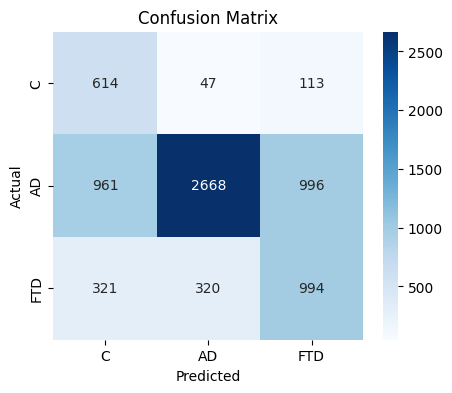

In [20]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["C", "AD", "FTD"],
    yticklabels=["C", "AD", "FTD"]
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


Using matplotlib as 2D backend.


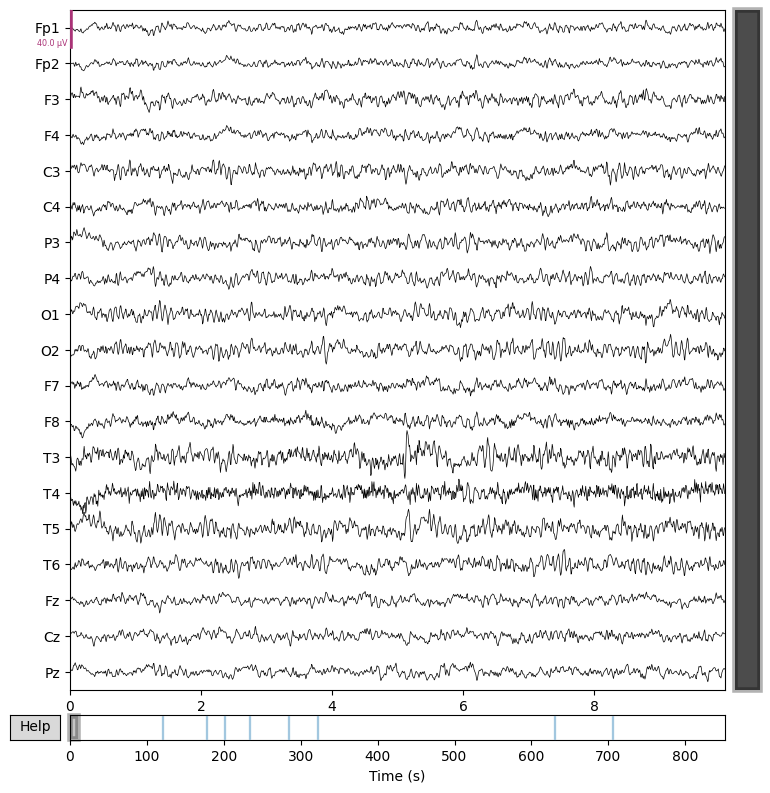

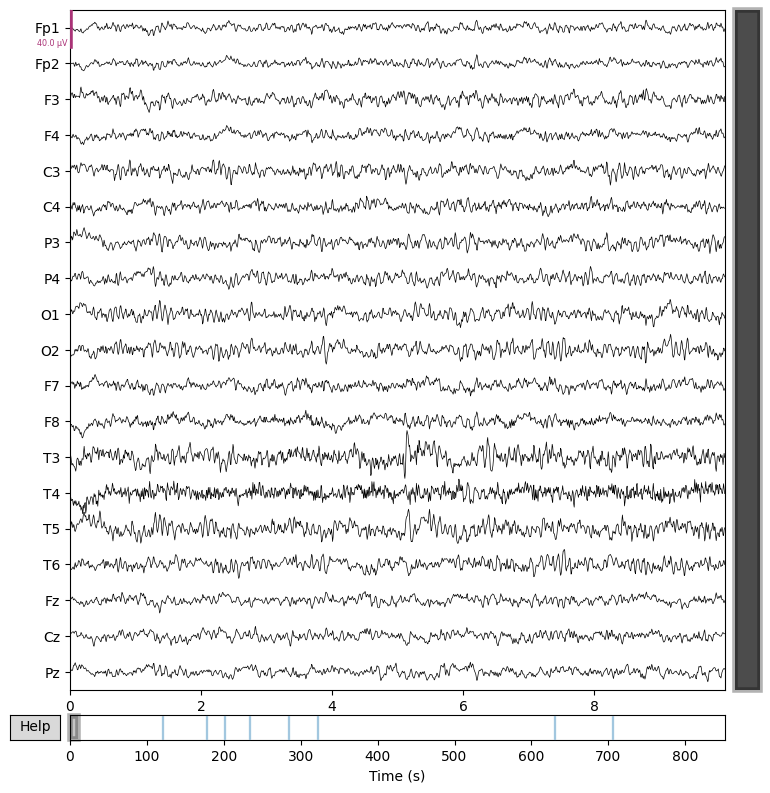

In [21]:
raw.plot()


In [22]:
raw.describe()


<RawEEGLAB | sub-045_task-eyesclosed_eeg.set, 19 x 425820 (851.6 s), ~61.8 MiB, data loaded>
ch  name  type  unit        min         Q1     median         Q3        max
 0  Fp1   EEG   µV       -26.84      -2.29      -0.01       2.25      23.78
 1  Fp2   EEG   µV       -25.51      -2.11      -0.02       2.10      22.80
 2  F3    EEG   µV       -47.21      -3.32      -0.01       3.29      38.11
 3  F4    EEG   µV       -86.29      -2.63      -0.00       2.61     112.97
 4  C3    EEG   µV       -46.46      -3.21       0.03       3.25      62.58
 5  C4    EEG   µV      -109.77      -2.87       0.03       2.89     103.74
 6  P3    EEG   µV       -33.76      -3.27       0.05       3.34      32.13
 7  P4    EEG   µV       -35.09      -2.98       0.02       3.03      31.61
 8  O1    EEG   µV       -38.40      -3.48       0.01       3.49      33.63
 9  O2    EEG   µV       -39.91      -3.60       0.01       3.59      38.84
10  F7    EEG   µV       -53.99      -3.04      -0.00       3.04      8

Now doing Cross Validation

In [23]:
from sklearn.model_selection import GroupKFold
from sklearn.metrics import accuracy_score, classification_report

gkf = GroupKFold(n_splits=5)

fold_accuracies = []
all_y_true = []
all_y_pred = []

for fold, (train_idx, test_idx) in enumerate(
    gkf.split(X_all, y_all, groups=subject_ids), 1
):
    print(f"\n========== Fold {fold} ==========")

    X_train, X_test = X_all[train_idx], X_all[test_idx]
    y_train, y_test = y_all[train_idx], y_all[test_idx]

    # Scale (fit only on train)
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    # Model
    model = LogisticRegression(
        max_iter=1000,
        multi_class="ovr"
    )

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    fold_accuracies.append(acc)

    print("Fold Accuracy:", acc)

    all_y_true.extend(y_test)
    all_y_pred.extend(y_pred)

print("\n==============================")
print("Mean CV Accuracy:", np.mean(fold_accuracies))
print("Std CV Accuracy:", np.std(fold_accuracies))

print("\nOverall Classification Report (CV):")
print(classification_report(
    all_y_true,
    all_y_pred,
    target_names=["Control", "AD", "FTD"]
))



========== Fold 1 ==========


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


Fold Accuracy: 0.520225919706915

========== Fold 2 ==========


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


Fold Accuracy: 0.6415535797847449

========== Fold 3 ==========


...

Fold Accuracy: 0.5506952038743946

========== Fold 4 ==========


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


Fold Accuracy: 0.5812900203029829

========== Fold 5 ==========


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


Fold Accuracy: 0.5957214241099313

Mean CV Accuracy: 0.5778972295557938
Std CV Accuracy: 0.04110297810593711

Overall Classification Report (CV):
              precision    recall  f1-score   support

     Control       0.52      0.51      0.51      9254
          AD       0.65      0.69      0.67     14550
         FTD       0.50      0.46      0.48      8366

    accuracy                           0.58     32170
   macro avg       0.56      0.55      0.55     32170
weighted avg       0.57      0.58      0.58     32170

